## Bias correction example

this illustratres use of bias correction functions

In [1]:
import xarray as xr
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
import cartopy.crs as ccrs
from acacia_s2s_toolkit.postprocess import postprocess_forecast, get_example_data, biascorrection_qqmapping, biascorrection_meanvariance

In [2]:
# let's see what the bias corection functions do
print(biascorrection_meanvariance.__doc__)


Apply mean and variance bias correction to forecast and hindcast data.

For each lead time, adjusts the mean and variance of the hindcast and
forecast to match those of the observed data. The correction is computed
from the hindcast/observation pair and then applied to both hindcast and
forecast.

Parameters
----------
forecast : xarray.DataArray
    Forecast data with dimensions (lead_time, member, ...).
hindcast : xarray.DataArray
    Hindcast data with dimensions (lead_time, member, init_date, ...).
observed : xarray.DataArray
    Observed data with dimensions (lead_time, init_date, ...).

Returns
-------
forecast_adjusted : xarray.DataArray
    Bias-corrected forecast, same shape as input forecast.
hindcast_adjusted : xarray.DataArray
    Bias-corrected hindcast, same shape as input hindcast.

Notes
-----
The correction follows:
    adjusted = ((x - mean(x)) * sqrt(var(obs) / var(hindcast))) + mean(obs)

Hindcast variance is computed over both member and init_date dimensions.
Grid

In [3]:
# let's see what the bias corection functions do
print(biascorrection_qqmapping.__doc__)


Apply quantile-quantile mapping bias correction to forecast and hindcast data.

For each lead time, maps the distribution of the hindcast and forecast
to match the observed distribution using quantile mapping. The transfer
function is derived from the hindcast/observation pair and applied to
both hindcast and forecast.

Parameters
----------
forecast : xarray.DataArray
    Forecast data with dimensions (lead_time, lat, lon, init_date, member).
hindcast : xarray.DataArray
    Hindcast data with dimensions (lead_time, lat, lon, init_date, member).
observed : xarray.DataArray
    Observed data with dimensions (lead_time, lat, lon, init_date).

Returns
-------
forecast_adjusted : xarray.DataArray
    Bias-corrected forecast, same shape as input forecast.
hindcast_adjusted : xarray.DataArray
    Bias-corrected hindcast, same shape as input hindcast.

Notes
-----
Member and init_date dimensions are stacked into a single sample dimension
before applying the quantile mapping, to maximise the 

## Getting some data to work with

In [4]:
#this is the data directory - you can change it as it suits you
data_dir="./data"

# this will load example data used in this notebook
# data are available at https://web.csag.uct.ac.za:~wolski/acacia/toolkit/
# comment this line if you want to work with your own data - 
# you will then have to define a file with observational data, and have 
# forecast and hindcast data for given initialization date downloaded to
# the data_dir

get_example_data(data_dir)

file already exists locally ./data/PRCPTOT_day_CHC_CHIRPS-2.0-0p25_merged.nc
file already exists locally ./data/tp_ECMWF_20260301_madagascar_hc.nc
file already exists locally ./data/tp_ECMWF_20260301_madagascar_fc.nc
file already exists locally ./data/madagascar.geojson


True

## Defining parameters for postprocessing

In [5]:
# defining what you want to process - i.e. forecast date, domain and observed dataset

# nominal forecast date is defined here. 
# This notebook uses example data for this date only
# example data are downloaded by a function get_example_data() called above

nominal_date="2026-03-01"
#target domain
target_domain="madagascar"
#forecast variable
fcst_var="tp"
#foreast model
fcst_model="ECMWF"

#this is file with observational data. It is gridded and covers the period of Jan 1981-March 2026
obs_file=f"{data_dir}/PRCPTOT_day_CHC_CHIRPS-2.0-0p25_merged.nc"

#we have to provide the name of the variable stored in the obs_file
obs_var="PRCPTOT"

# this is a file with vector data showing the boundaries of the domain - will be used in plotting only
domain_shape_file=f"{data_dir}/madagascar.geojson"

# data will be aggregated into blocks of this size - "5D" is a Pandas expression of temporal base and stands for 5 days
# if you want differently sized blocks - just change it into, say "7D"
agg_window="5D"

#and this defines how data will be aggreagated over the block - in this case it will be a sum of daily values
agg_method="sum"

# this defines regridding parameters for matching the obs and forecast grids. 
# it assumes obs grid is finer, so fine_to_coarse will give forecast grid, coarse_to_fine will give obs grid
# raise_if_missing will stop processing if the spatial overlap between obs and forecast grids of less than fractional 
# threshold
grid_alignment_kwargs=dict(
    direction="fine_to_coarse",
    method="conservative",
    raise_if_missing=True,
    threshold=0.9
)

# this defines time alignment parameter for matching the obs and hindcast time series. 
# raise_if_missing will stop processing if any of the hindcast days are not covered by observations 
time_alignment_kwargs={"raise_if_missing":True}

In [6]:
# calling the preprocessing wrapper
hindcast_lt,forecast_lt,obs_lt=postprocess_forecast(
    nominal_date=nominal_date,
    download_dir=data_dir,
    target_domain=target_domain,
    fcst_var=fcst_var,
    fcst_model=fcst_model,
    agg_window=agg_window,
    agg_method=agg_method,
    obs_file=obs_file,
    obs_var=obs_var,
    grid_alignment_kwargs=grid_alignment_kwargs,
    time_alignment_kwargs=time_alignment_kwargs,
    verbose=False
)

logging is False
nominal forecast date: 2026-03-01
download dir: ./data
domain: madagascar
model: ECMWF
forecast variable: tp
aggregation window: 5D
observed file: ./data/PRCPTOT_day_CHC_CHIRPS-2.0-0p25_merged.nc
observed variable: PRCPTOT
postprocessing done


In [7]:
#applying the mean and variance bias correction
forecast_bc_mv,hindcast_bc_mv=biascorrection_meanvariance(forecast_lt, hindcast_lt, obs_lt)

/home/piotr/miniforge3/envs/s2stoolkit_dev/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/piotr/miniforge3/envs/s2stoolkit_dev/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/piotr/miniforge3/envs/s2stoolkit_dev/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/piotr/miniforge3/envs/s2stoolkit_dev/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/piotr/miniforge3/envs/s2stoolkit_dev/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997

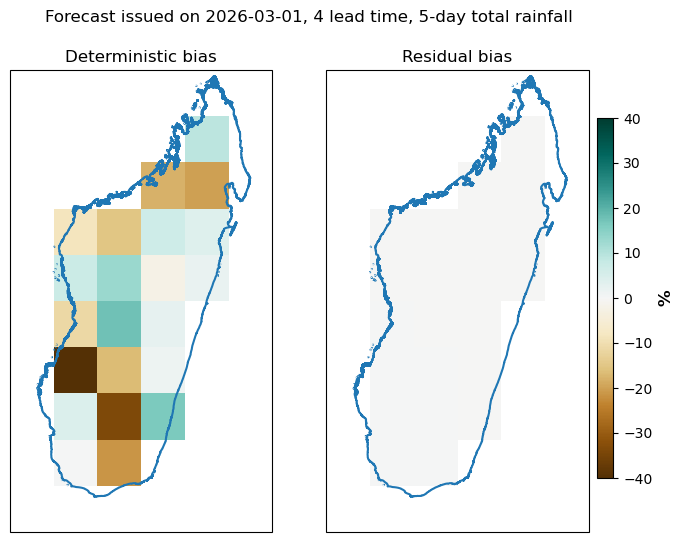

In [8]:
# plotting  deterministic bias - mean difference between obs and median of the hindcast ensemble
lead_time=4

fig=plt.figure(figsize=(8,6))


# plotting bias in original data
pl=fig.add_subplot(1,2,1, projection=ccrs.PlateCarree())

#calculating climatology in obs and hindcast
ob=obs_lt.isel(lead_time=lead_time).mean("init_date")
hc=hindcast_lt.mean("member").isel(lead_time=lead_time).mean("init_date")

#calculating bias as percentage of obs value
bias=((ob-hc)/ob)*100
#plotting
im=bias.plot(add_colorbar=False, vmin=-40, vmax=40, cmap=plt.cm.BrBG)
#adding overlay
overlay=gpd.read_file(domain_shape_file)
overlay.boundary.plot(ax=pl)

pl.set_title("Deterministic bias")


#plotting bias in bias-corrected data

pl=fig.add_subplot(1,2,2, projection=ccrs.PlateCarree())

#calculating climatology in obs and in bias-corrected hindcast
ob=obs_lt.isel(lead_time=lead_time).mean("init_date")
hc_bc=hindcast_bc_mv.mean("member").isel(lead_time=lead_time).mean("init_date")

#calculating residual bias as percentage of obs value
bias_bc=((ob-hc_bc)/ob)*100
#plotting
im=bias_bc.plot(add_colorbar=False, vmin=-40, vmax=40, cmap=plt.cm.BrBG)
#adding colorbar
ax=fig.add_axes([0.86,0.2,0.02,0.6])
cbar = plt.colorbar(im, cax=ax)
cbar.set_label('%', size=12, weight='bold')
#adding overlay
overlay=gpd.read_file(domain_shape_file)
overlay.boundary.plot(ax=pl)

pl.set_title("Residual bias")

plt.subplots_adjust(right=0.85)
plt.suptitle("Forecast issued on {}, {} lead time, {}-day total rainfall".format(nominal_date, lead_time, agg_window[:-1]))
plt.show()




In [9]:
#now let's try with the quantile mapping approach
forecast_bc_qq,hindcast_bc_qq=biascorrection_qqmapping(forecast_lt, hindcast_lt, obs_lt)

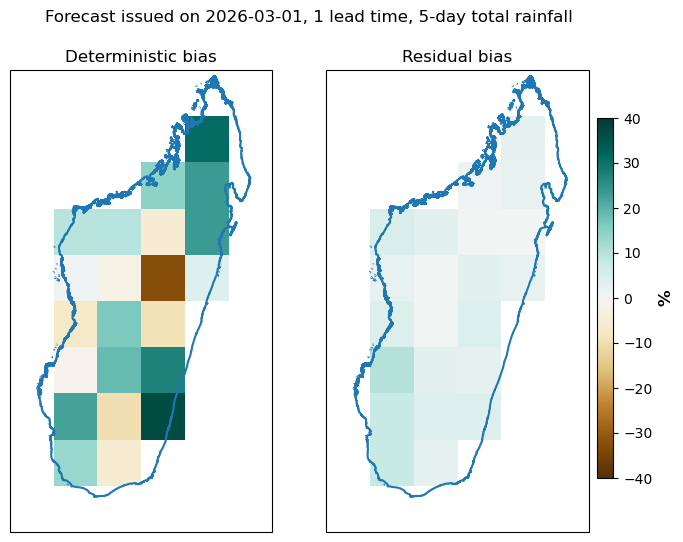

In [10]:
# plotting  deterministic bias - mean difference between obs and median of the hindcast ensemble
lead_time=1

fig=plt.figure(figsize=(8,6))


# plotting bias in original data
pl=fig.add_subplot(1,2,1, projection=ccrs.PlateCarree())

#calculating climatology in obs and hindcast
ob=obs_lt.isel(lead_time=lead_time).mean("init_date")
hc=hindcast_lt.mean("member").isel(lead_time=lead_time).mean("init_date")

#calculating bias as percentage of obs value
bias=((ob-hc)/ob)*100
#plotting
im=bias.plot(add_colorbar=False, vmin=-40, vmax=40, cmap=plt.cm.BrBG)
#adding overlay
overlay=gpd.read_file(domain_shape_file)
overlay.boundary.plot(ax=pl)

pl.set_title("Deterministic bias")


#plotting bias in bias-corrected data

pl=fig.add_subplot(1,2,2, projection=ccrs.PlateCarree())

#calculating climatology in obs and in bias-corrected hindcast
ob=obs_lt.isel(lead_time=lead_time).mean("init_date")
hc_bc=hindcast_bc_qq.mean("member").isel(lead_time=lead_time).mean("init_date")

#calculating residual bias as percentage of obs value
bias_bc=((ob-hc_bc)/ob)*100
#plotting
im=bias_bc.plot(add_colorbar=False, vmin=-40, vmax=40, cmap=plt.cm.BrBG)
#adding colorbar
ax=fig.add_axes([0.86,0.2,0.02,0.6])
cbar = plt.colorbar(im, cax=ax)
cbar.set_label('%', size=12, weight='bold')
#adding overlay
overlay=gpd.read_file(domain_shape_file)
overlay.boundary.plot(ax=pl)

pl.set_title("Residual bias")

plt.subplots_adjust(right=0.85)
plt.suptitle("Forecast issued on {}, {} lead time, {}-day total rainfall".format(nominal_date, lead_time, agg_window[:-1]))
plt.show()




Quantile mapping produces a small residual bias, but one has to consider that there is a difference between mean and median, and the qq bias correction adjusts for median of the distribution rathe than for mean, while the biascorrection_meanvariance function adjusts mean explicitly. Let's illustrate the effects of bias correction using distributions

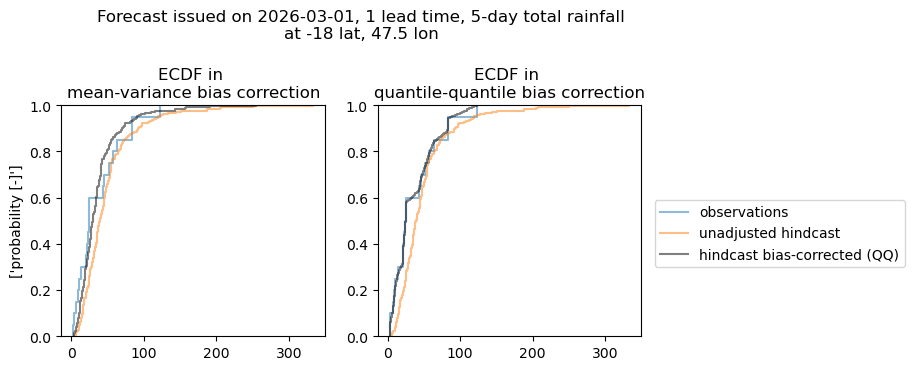

In [11]:
# plotting distributions in original and bias-corrected data

#selecting lead time
lead_time=1

#selecting a location
lat,lon=-18,47.5

fig=plt.figure(figsize=(8,3))

# plotting distribution in original data
pl=fig.add_subplot(1,2,1)

ob=obs_lt.isel(lead_time=lead_time).sel(lat=lat,lon=lon, method="nearest")
hc=hindcast_lt.isel(lead_time=lead_time).sel(lat=lat,lon=lon, method="nearest")
hc_bc_mv=hindcast_bc_mv.isel(lead_time=lead_time).sel(lat=lat,lon=lon, method="nearest")

pl.ecdf(ob.data, alpha=0.5, label="observations")
pl.ecdf(hc.data.flatten(), alpha=0.5, label="unadjusted hindcast")
pl.ecdf(hc_bc_mv.data.flatten(), alpha=0.5, label="hindcast bias-corrected (MV)", color="black")

pl.set_title("ECDF in \nmean-variance bias correction")
pl.set_ylabel(["probability [-]"])


#plotting bias in bias-corrected data

pl=fig.add_subplot(1,2,2)

hc_bc_qq=hindcast_bc_qq.isel(lead_time=lead_time).sel(lat=lat,lon=lon, method="nearest")

pl.ecdf(ob.data, alpha=0.5, label="observations")
pl.ecdf(hc.data.flatten(), alpha=0.5, label="unadjusted hindcast")
pl.ecdf(hc_bc_qq.data.flatten(), alpha=0.5, label="hindcast bias-corrected (QQ)", color="black")

pl.set_title("ECDF in \nquantile-quantile bias correction")

plt.suptitle("Forecast issued on {}, {} lead time, {}-day total rainfall\nat {} lat, {} lon".format(nominal_date, lead_time, agg_window[:-1], lat,lon), y=1.2)

plt.legend(loc=(1.05, 0.3))

plt.subplots_adjust(right=0.85)

plt.show()


